# BIDS → openMINDS Workflow Demo

**Dataset:** [OpenNeuro ds000248 v1.2.4](https://openneuro.org/datasets/ds000248/versions/1.2.4)  
**Subject:** sub-01 only (MEG + MRI)  

This notebook demonstrates a complete workflow:

1. **Download** one subject from OpenNeuro
2. **Read** raw data with MNE-Python
3. **Re-export** to BIDS using MNE-BIDS
4. **Validate** the BIDS dataset
5. **Visualize** a data segment
6. **Generate** openMINDS metadata with bids2openminds
7. **Validate** the openMINDS output

## Setup

Import libraries and create the working directory structure.

**Required packages:** `mne`, `mne-bids`, `bids-validator`, `bids2openminds`, `openminds`, `matplotlib`, `openneuro-py`  
**Required CLI tools:** `bids-validator` (Node.js, via `npm install -g bids-validator`)

In [1]:
from pathlib import Path
import subprocess
import shutil
import json
import sys

import mne
import mne_bids
from mne_bids import BIDSPath, read_raw_bids, write_raw_bids

# Working directories
project_root = Path.cwd()
data_input = project_root / "data_input"
data_bids = project_root / "data_bids"
reports = project_root / "reports"
openminds_dir = project_root / "openminds_metadata"

for d in [data_input, data_bids, reports, openminds_dir]:
    d.mkdir(exist_ok=True)
    print(f"Directory ready: {d.relative_to(project_root)}")

print(f"\nMNE {mne.__version__} | MNE-BIDS {mne_bids.__version__}")

Directory ready: data_input
Directory ready: data_bids
Directory ready: reports
Directory ready: openminds_metadata

MNE 1.11.0 | MNE-BIDS 0.18.0


## Step 1: Download Dataset from OpenNeuro



In [8]:
import openneuro

dataset_dir = data_input / "ds000248"
meg_file = dataset_dir / "sub-01" / "meg" / "sub-01_task-audiovisual_run-01_meg.fif"

if meg_file.exists():
    print(f"Dataset already downloaded at: {dataset_dir}")
else:
    # Clear partial downloads if any
    if dataset_dir.exists():
        shutil.rmtree(dataset_dir)
    print("Downloading ds000248 (excluding sub-emptyroom) from OpenNeuro...")
    openneuro.download(
        dataset="ds000248",
        tag="1.2.4",
        target_dir=str(dataset_dir),
        exclude=["sub-emptyroom"],
    )
    print("Download complete.")

print(f"\nDataset contents:")
for p in sorted(dataset_dir.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(dataset_dir)}")

Dataset already downloaded at: /workspaces/bids-openminds-demo/data_input/ds000248

Dataset contents:
  CHANGES
  README
  acq-epi_T1w.json
  dataset_description.json
  derivatives/freesurfer/subjects/fsaverage/bem/brain.surf
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-5120-5120-5120-bem-sol.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-5120-5120-5120-bem.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-fiducials.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-head-dense.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-head-medium.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-head.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-ico-5-src.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-inner_skull-bem.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-trans.fif
  derivatives/freesurfer/subjects/fsaverage/bem/fsaverage-vol-5-src.fif
  derivatives/freesurfer/subject

## Step 2: Read Data with MNE-Python



In [9]:
bids_root = data_input / "ds000248"

# Discover MEG files for sub-01
matching = BIDSPath(
    subject="01", task="audiovisual", datatype="meg", suffix="meg", root=bids_root
).match()

if not matching:
    raise FileNotFoundError(f"No MEG files found for sub-01 in {bids_root}")

bids_path = matching[0]
print(f"BIDS path: {bids_path}")
print(f"File:      {bids_path.fpath.name}")

# Read and load raw data
raw = read_raw_bids(bids_path, verbose="WARNING")
raw.load_data()

print(f"\n--- Data Summary ---")
print(f"Channels:    {raw.info['nchan']}")
print(f"Sample rate: {raw.info['sfreq']} Hz")
print(f"Duration:    {raw.times[-1]:.1f} s")
print(f"Ch. types:   {sorted(set(raw.get_channel_types()))}")

BIDS path: /workspaces/bids-openminds-demo/data_input/ds000248/sub-01/meg/sub-01_task-audiovisual_run-01_meg.fif
File:      sub-01_task-audiovisual_run-01_meg.fif
Reading 0 ... 166799  =      0.000 ...   277.714 secs...

--- Data Summary ---
Channels:    376
Sample rate: 600.614990234375 Hz
Duration:    277.7 s
Ch. types:   ['eeg', 'eog', 'grad', 'mag', 'stim']


## Step 3: Re-export to BIDS Using MNE-BIDS



In [10]:
# Extract events from annotations (set by read_raw_bids from events.tsv)
events, event_id = mne.events_from_annotations(raw)
print(f"Events: {len(events)} across {len(event_id)} categories")

# Define output BIDS path
output_bids_path = BIDSPath(
    subject="01",
    task=bids_path.task,
    run=bids_path.run,
    datatype="meg",
    root=data_bids,
)

print(f"Writing BIDS to: {data_bids}")
write_raw_bids(
    raw,
    bids_path=output_bids_path,
    events=events,
    event_id=event_id,
    overwrite=True,
    allow_preload=True,
    format="FIF",
    verbose="WARNING",
)
print("\nBIDS export complete. Output files:")
for p in sorted(data_bids.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(data_bids)}")

Used Annotations descriptions: [np.str_('Auditory/Left'), np.str_('Auditory/Right'), np.str_('Button'), np.str_('Smiley'), np.str_('Visual/Left'), np.str_('Visual/Right')]
Events: 320 across 6 categories
Writing BIDS to: /workspaces/bids-openminds-demo/data_bids

BIDS export complete. Output files:
  .gitkeep
  README
  dataset_description.json
  participants.json
  participants.tsv
  sub-01/meg/sub-01_coordsystem.json
  sub-01/meg/sub-01_task-audiovisual_run-01_channels.tsv
  sub-01/meg/sub-01_task-audiovisual_run-01_events.json
  sub-01/meg/sub-01_task-audiovisual_run-01_events.tsv
  sub-01/meg/sub-01_task-audiovisual_run-01_meg.fif
  sub-01/meg/sub-01_task-audiovisual_run-01_meg.json
  sub-01/sub-01_scans.tsv


## Step 4: Validate the BIDS Dataset



In [11]:
import os
os.environ["PATH"] = str(Path.home() / ".nvm/versions/node/v24.14.0/bin") + ":" + os.environ.get("PATH", "")

report_path = reports / "bids_validation_report.txt"

# Find available validator
cmd = None
if shutil.which("bids-validator"):
    cmd = ["bids-validator", str(data_bids)]
elif shutil.which("npx"):
    print("bids-validator CLI not found, falling back to npx...")
    cmd = ["npx", "bids-validator", str(data_bids)]
else:
    print("WARNING: Neither bids-validator nor npx found.")
    print("Install via: npm install -g bids-validator")

if cmd:
    print(f"Running: {' '.join(cmd)}\n")
    result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
    output = (result.stdout + "\n" + result.stderr).strip()
    report_path.write_text(output)
    print(f"Exit code: {result.returncode}")
    print(f"Report saved: {report_path.relative_to(project_root)}")
    print(f"\n{output[:3000]}")
else:
    report_path.write_text("BIDS validator not available on this system.\n")
    print(f"Report saved: {report_path.relative_to(project_root)}")

bids-validator CLI not found, falling back to npx...
Running: npx bids-validator /workspaces/bids-openminds-demo/data_bids

Exit code: 0
Report saved: reports/bids_validation_report.txt

bids-validator@1.15.0
This dataset appears to be BIDS compatible.
        Summary:                  Available Tasks:        Available Modalities: 
        11 Files, 122.59MB        audiovisual             MEG                   
        1 - Subject                                                             
        1 - Session                                                             


	If you have any questions, please post on https://neurostars.org/tags/bids.

npm warn exec The following package was not found and will be installed: bids-validator@1.15.0
npm warn deprecated git-semver-tags@5.0.1: This package is no longer maintained. For the JavaScript API, please use @conventional-changelog/git-client instead.
npm warn deprecated git-raw-commits@3.0.0: This package is no longer maintained. For the

## Step 5: Visualize the Data

Plot a short segment of the MEG signal and save the figure to `reports/data_visualization.png`.

Using matplotlib as 2D backend.


Plotting 10-second segment of raw MEG data...
Saved: reports/data_visualization.png


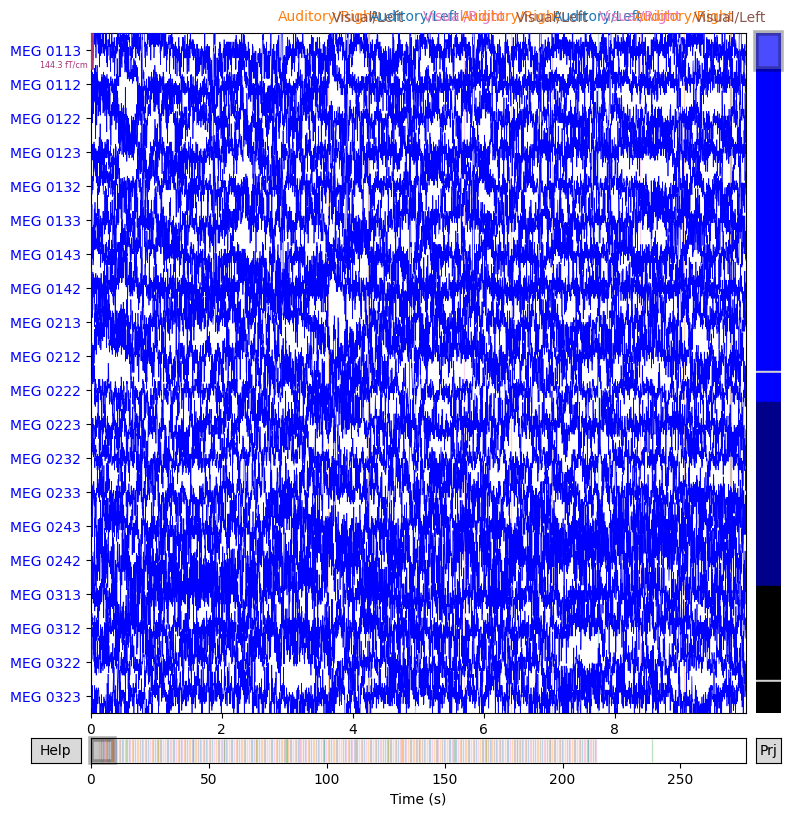

In [12]:
import matplotlib.pyplot as plt
import numpy as np

try:
    mne.viz.set_browser_backend("matplotlib")
except Exception:
    pass

fig_path = reports / "data_visualization.png"
print("Plotting 10-second segment of raw MEG data...")

try:
    fig = raw.plot(duration=10, n_channels=20, scalings="auto", show=False)
except Exception as e:
    # Fallback: manual matplotlib plot if MNE browser backend fails
    print(f"MNE raw.plot() unavailable ({e}), using manual plot...")
    picks = mne.pick_types(raw.info, meg="grad")[:10]
    data, times = raw[picks, : int(10 * raw.info["sfreq"])]
    fig, axes = plt.subplots(len(picks), 1, figsize=(14, 8), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(times, data[i] * 1e13, linewidth=0.3, color="steelblue")
        ax.set_ylabel(raw.ch_names[picks[i]], fontsize=7, rotation=0, ha="right")
        ax.tick_params(labelsize=7)
        ax.margins(x=0)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("MEG Gradiometers — First 10 Seconds (sub-01)")
    fig.tight_layout()

fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved: {fig_path.relative_to(project_root)}")
plt.show()

## Step 6: Generate openMINDS Metadata


Output goes to `openminds_metadata/`, logs to `reports/bids2openminds_report.txt`.

In [13]:
report_path = reports / "bids2openminds_report.txt"

desc_path = data_bids / "dataset_description.json"
if desc_path.exists():
    desc = json.loads(desc_path.read_text())
    patched = False
    if desc.get("Name", "").startswith("[Unspecified"):
        desc["Name"] = "ds000248: Auditory and visual stimuli MEG dataset"
        patched = True
    if any(a.startswith("[Unspecified") for a in desc.get("Authors", [])):
        desc["Authors"] = ["Alexandre Gramfort"]
        patched = True
    if patched:
        desc_path.write_text(json.dumps(desc, indent=4) + "\n")
        print("Patched dataset_description.json (name + authors)")


participants_tsv = data_bids / "participants.tsv"
if participants_tsv.exists():
    print(f"\nOriginal participants.tsv:")
    print(f"  {participants_tsv.read_text().strip()}")

    lines = participants_tsv.read_text().splitlines()
    header = lines[0].split("\t")
    # Valid placeholder values for each column
    defaults = {"hand": "R", "age": "25", "sex": "M", "weight": "70", "height": "175"}
    new_lines = [lines[0]]
    for line in lines[1:]:
        cols = line.split("\t")
        for col_name, default_val in defaults.items():
            if col_name in header:
                idx = header.index(col_name)
                if idx < len(cols) and cols[idx] in ("n/a", "nan", "NaN", ""):
                    print(f"  Patching '{col_name}': '{cols[idx]}' → '{default_val}'")
                    cols[idx] = default_val
        new_lines.append("\t".join(cols))
    participants_tsv.write_text("\n".join(new_lines) + "\n")

    print(f"\nPatched participants.tsv:")
    print(f"  {participants_tsv.read_text().strip()}")


output_file = openminds_dir / "openminds.jsonld"

if shutil.which("bids2openminds"):
    cmd = ["bids2openminds", str(data_bids), "-o", str(output_file), "--single-file"]
else:
    print("\nbids2openminds CLI not in PATH, running as Python module...")
    cmd = [sys.executable, "-m", "bids2openminds", str(data_bids), "-o", str(output_file), "--single-file"]

print(f"\nRunning: {' '.join(cmd)}\n")
result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)

output = (result.stdout + "\n" + result.stderr).strip()
report_path.write_text(output)

print(f"Exit code: {result.returncode}")
print(f"Report saved: {report_path.relative_to(project_root)}")
print(f"\n{output[:3000]}")

# List generated files
generated = [f for f in openminds_dir.rglob("*") if f.is_file()]
if generated:
    print(f"\nGenerated {len(generated)} file(s):")
    for f in sorted(generated):
        print(f"  {f.relative_to(openminds_dir)}")
else:
    print("\nWARNING: No files were generated. Check the report above.")

Patched dataset_description.json (name + authors)

Original participants.tsv:
  ﻿participant_id	age	sex	hand	weight	height
sub-01	n/a	n/a	n/a	n/a	n/a
  Patching 'hand': 'n/a' → 'R'
  Patching 'age': 'n/a' → '25'
  Patching 'sex': 'n/a' → 'M'
  Patching 'weight': 'n/a' → '70'
  Patching 'height': 'n/a' → '175'

Patched participants.tsv:
  ﻿participant_id	age	sex	hand	weight	height
sub-01	25	M	R	70	175

Running: bids2openminds /workspaces/bids-openminds-demo/data_bids -o /workspaces/bids-openminds-demo/openminds_metadata/openminds.jsonld --single-file

Exit code: 0
Report saved: reports/bids2openminds_report.txt

Conversion Report
Conversion was successful, the openMINDS file is in /workspaces/bids-openminds-demo/openminds_metadata/openminds.jsonld

Dataset title : ds000248: Auditory and visual stimuli MEG dataset


Experimental approaches detected:
------------------------------------------ 
neuroimaging


Detected data types:
------------------------------------------
raw data


The fo

## Step 7: Validate openMINDS Output



Results are saved to `reports/openminds_validation_report.txt`.

In [14]:
report_path = reports / "openminds_validation_report.txt"
log = []

# Find metadata files
metadata_files = sorted(
    list(openminds_dir.rglob("*.jsonld")) + list(openminds_dir.rglob("*.json"))
)

if not metadata_files:
    msg = "No JSON-LD or JSON metadata files found in openminds_metadata/."
    log.append(msg)
    print(f"WARNING: {msg}")
else:
    print(f"Validating {len(metadata_files)} metadata file(s):\n")
    for f in metadata_files:
        try:
            data = json.loads(f.read_text())
            has_ld = any(k.startswith("@") for k in data if isinstance(data, dict))
            status = "PASS" if has_ld else "WARN (no JSON-LD markers)"
            log.append(f"{status}: {f.name}")
            print(f"  {status}: {f.name}")
        except json.JSONDecodeError as e:
            log.append(f"FAIL: {f.name} — {e}")
            print(f"  FAIL: {f.name} — {e}")


print()
try:
    import openminds
    log.append(f"\nopenminds version: {openminds.__version__}")
    print(f"openminds package v{openminds.__version__} loaded.")

    if hasattr(openminds, "Collection"):
        collection = openminds.Collection()
        for f in metadata_files:
            collection.load(str(f))
        if hasattr(collection, "validate"):
            errors = collection.validate()
            msg = f"Validation errors: {errors}" if errors else "Validation passed (no errors)."
            log.append(msg)
            print(msg)
        else:
            log.append("Collection loaded successfully (no validate method).")
            print("Collection loaded successfully.")
    else:
        log.append("No Collection class available; structural validation only.")
        print("Structural JSON-LD validation only (no Collection API).")
except Exception as e:
    log.append(f"openminds validation note: {e}")
    print(f"openminds note: {e}")

report_path.write_text("\n".join(log))
print(f"\nReport saved: {report_path.relative_to(project_root)}")

Validating 1 metadata file(s):

  PASS: openminds.jsonld

openminds package v0.5.0 loaded.
openminds note: Type 'https://openminds.ebrains.eu/core/SubjectState' was not found in the registry for version v5.

Report saved: reports/openminds_validation_report.txt


## Summary

In [15]:
print("=" * 60)
print("WORKFLOW SUMMARY")
print("=" * 60)

outputs = {
    "BIDS dataset":              data_bids,
    "BIDS validation report":    reports / "bids_validation_report.txt",
    "Data visualization":        reports / "data_visualization.png",
    "bids2openminds report":     reports / "bids2openminds_report.txt",
    "openMINDS metadata":        openminds_dir,
    "openMINDS validation":      reports / "openminds_validation_report.txt",
}

for label, path in outputs.items():
    exists = "OK" if path.exists() else "MISSING"
    print(f"  [{exists:>7}]  {label}: {path.relative_to(project_root)}")

print("=" * 60)

WORKFLOW SUMMARY
  [     OK]  BIDS dataset: data_bids
  [     OK]  BIDS validation report: reports/bids_validation_report.txt
  [     OK]  Data visualization: reports/data_visualization.png
  [     OK]  bids2openminds report: reports/bids2openminds_report.txt
  [     OK]  openMINDS metadata: openminds_metadata
  [     OK]  openMINDS validation: reports/openminds_validation_report.txt
